# MATHFI model pipeline with quantitative biomarkers and visualization

In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
# --- Imports ---
%matplotlib inline
import os, time, json, contextlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# --- Your libs ---
from src.data.preprocessing import _iso_resize_and_pad
from apps.streamlit.lib.preprocess import preprocess_image_retina_from_pil  # <--- or your path where preprocess.py lives

# Vessel metrics
from src.retina_biomarkers import (
    to_bool_mask, skeletonize_mask, distance_transform, build_skeleton_graph,
    sample_width_along_skeleton, sample_widths_orthogonal,
    area_density, length_density, caliber_stats, tortuosity_stats, fractal_dimension_boxcount,
    junction_metrics, branching_and_bifurcation_angles, branching_angles_roi, gap_metrics, metrics_by_rings,
    collect_orthogonal_chords,
    plot_vessel_widths_overlay, 
)

# OD segmentation helpers (from the od_seg package we made)
from src.retina_biomarkers.od_seg import (
    load_refuge_segformer, infer_label_map, extract_disc_mask_safe,
    center_and_pd_with_bounds, show_disc_overlay
)


In [3]:
# --- Model helpers (use your DPCNConcatUNet and load from .pth) ---
import torch, contextlib

from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet

def build_dpcn_model(device: str | None = None) -> tuple[torch.nn.Module, str]:
    dev = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = DPCNConcatUNet(
        in_ch=1,                 # grayscale
        enh_channels=64,         # DPCN internal channels (C)
        iters=6,                 # DPCN iterations (T)
        threshold_mode="scaled_vat",
        half_life=2.0,           # E memory ~2 iterations
        reduce_to=64,            # compress T*C to control memory
        base_kwargs={"cbam_reduction": 16},
        refine_edge=True
    ).to(dev).eval()
    return model, dev

def _strip_prefix_if_present(state_dict: dict, prefix: str = "module.") -> dict:
    if not any(k.startswith(prefix) for k in state_dict.keys()):
        return state_dict
    return {k[len(prefix):] if k.startswith(prefix) else k: v for k, v in state_dict.items()}

def load_weights_into_model(model: torch.nn.Module, ckpt_path: str, device: str) -> None:
    state = torch.load(ckpt_path, map_location=device)
    # handle common wrappers
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    # try strict, then try removing "module." prefix if needed
    try:
        model.load_state_dict(state, strict=True)
        return
    except Exception:
        pass
    try:
        state2 = _strip_prefix_if_present(state, "module.")
        model.load_state_dict(state2, strict=True)
        return
    except Exception as e:
        print("[warn] strict load failed; trying non-strict:", e)
        model.load_state_dict(state2, strict=False)

def load_dpcn_from_ckpt(ckpt_path: str, device: str | None = None) -> tuple[torch.nn.Module, str]:
    model, dev = build_dpcn_model(device)
    load_weights_into_model(model, ckpt_path, dev)
    model.eval()
    return model, dev


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def _draw_pd_rings(ax, center_yx, PD_px, *, max_PD=3.0, step_PD=0.5, ring_color='cyan'):
    if center_yx is None or PD_px is None: 
        return
    cy, cx = center_yx
    theta = np.linspace(0, 2*np.pi, 512)
    ax.scatter([cx], [cy], s=36, marker='x', color='yellow')
    for k in np.arange(step_PD, max_PD + 1e-9, step_PD):
        r = k * PD_px
        xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
        ax.plot(xx, yy, color=ring_color, linewidth=1.2)
    # dashed 2-PD
    r = 2.0 * PD_px
    xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
    ax.plot(xx, yy, color=ring_color, linestyle="--", linewidth=1.4)

def visualize_grid(out, *, overlay_alpha=0.35):
    """
    Layout:
      Row 1: raw, ISO-resized/padded, OD+PD rings
      Row 2: preprocessed (CLAHE+gamma), model prob, final seg (thr 0.5)
    """
    raw_rgb     = out["raw_rgb"]
    rgb_iso     = out["rgb_iso"]
    disc_mask   = out["disc_mask"]
    center_yx   = tuple(out["od"]["center_yx"])
    PD_px       = out["od"]["PD_px"]
    pre_gray_u8 = out["pre_gray_u8"]
    prob_map    = out["prob_map"]
    mask_thr05  = out["pred_mask_thr05"]

    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    axs = axs.ravel()

    # (1) Raw
    axs[0].imshow(raw_rgb); axs[0].set_title("Raw fundus (original)"); axs[0].axis('off')

    # (2) ISO-resized/padded
    axs[1].imshow(rgb_iso); axs[1].set_title("ISO-resized/padded RGB"); axs[1].axis('off')

    # (3) OD + PD rings
    axs[2].imshow(rgb_iso); axs[2].set_title("Optic disc + PD rings"); axs[2].axis('off')
    try:
        axs[2].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.5)
    except Exception:
        pass
    _draw_pd_rings(axs[2], center_yx, PD_px)

    # (4) Preprocessed grayscale (CLAHE+gamma)
    # pre_gray_u8 is uint8 -> natural for imshow
    axs[3].imshow(pre_gray_u8, cmap='gray', vmin=0, vmax=255)
    axs[3].set_title("Preprocessed (CLAHE + gamma)"); axs[3].axis('off')

    # (5) Probability map
    im5 = axs[4].imshow(prob_map, vmin=0, vmax=1); axs[4].set_title("Model probability map"); axs[4].axis('off')
    plt.colorbar(im5, ax=axs[4], fraction=0.046, pad=0.04)

    # (6) Final segmented result @ threshold 0.5
    axs[5].imshow(mask_thr05, cmap='gray', vmin=0, vmax=1)
    axs[5].set_title("Segmentation (threshold = 0.5)"); axs[5].axis('off')

    plt.tight_layout(); plt.show()

def visualize_overlay(out, *, overlay_alpha=0.35):
    """
    A separate overlay: vessels (green alpha) + OD contour + PD rings on ISO RGB.
    """
    rgb_iso    = out["rgb_iso"]
    disc_mask  = out["disc_mask"]
    center_yx  = tuple(out["od"]["center_yx"])
    PD_px      = out["od"]["PD_px"]
    mask_thr05 = out["pred_mask_thr05"]

    overlay = np.zeros_like(rgb_iso, dtype=np.uint8)
    overlay[..., 1] = (mask_thr05.astype(np.uint8) * 255)  # green channel

    plt.figure(figsize=(6.5, 6.5))
    plt.imshow(rgb_iso); plt.axis('off'); plt.title("Vessels + OD + PD rings overlay")
    plt.imshow(overlay, alpha=overlay_alpha)
    try:
        plt.contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.2)
    except Exception:
        pass
    _draw_pd_rings(plt.gca(), center_yx, PD_px, ring_color='white')
    plt.show()

def visualize_pipeline_stages(
    *, raw_rgb, rgb_iso, disc_mask, center_yx, PD_px,
    pre_gray_u8, prob_map=None, pred_mask=None, overlay_alpha=0.35
):
    """
    Shows: (1) raw image, (2) ISO-resized, (3) ISO + OD+rings,
           (4) preprocessed grayscale, (5) probability map, (6) final overlay.
    All visuals are in the ISO frame to keep geometry aligned.
    """
    # safety defaults
    H, W = rgb_iso.shape[:2]
    if prob_map is None:
        prob_map = np.zeros((H, W), dtype=np.float32)
    if pred_mask is None:
        pred_mask = np.zeros((H, W), dtype=np.uint8)

    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    axs = axs.ravel()

    # (1) Raw
    axs[0].imshow(raw_rgb); axs[0].set_title("Raw fundus (original)"); axs[0].axis('off')

    # (2) ISO-resized
    axs[1].imshow(rgb_iso); axs[1].set_title("ISO-resized / padded RGB"); axs[1].axis('off')

    # (3) ISO + OD + rings
    axs[2].imshow(rgb_iso); axs[2].set_title("Optic disc + PD rings"); axs[2].axis('off')
    try:
        axs[2].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.5)
    except Exception:
        pass
    _draw_pd_rings(axs[2], center_yx, PD_px, ring_kwargs=dict(color='cyan'))

    # (4) Preprocessed grayscale
    axs[3].imshow(pre_gray_u8, cmap='gray'); axs[3].set_title("Preprocessed (CLAHE + gamma)"); axs[3].axis('off')

    # (5) Probability map
    im5 = axs[4].imshow(prob_map, vmin=0, vmax=1); axs[4].set_title("Model probability map"); axs[4].axis('off')
    plt.colorbar(im5, ax=axs[4], fraction=0.046, pad=0.04)

    # (6) Final overlay: vessels + OD rings on ISO RGB
    axs[5].imshow(rgb_iso); axs[5].set_title("Vessels + OD rings overlay"); axs[5].axis('off')
    # green translucent vessel mask
    overlay = np.zeros_like(rgb_iso, dtype=np.uint8)
    overlay[..., 1] = (pred_mask.astype(np.uint8) * 255)
    axs[5].imshow(overlay, alpha=overlay_alpha)
    # OD contour + rings
    try:
        axs[5].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.2)
    except Exception:
        pass
    _draw_pd_rings(axs[5], center_yx, PD_px, ring_kwargs=dict(color='white'))

    plt.tight_layout()
    plt.show()


In [5]:
IMAGE_SIZE       = 512
THRESHOLD        = 0.5
R_FRAC           = (0.08, 0.16)   # PD radius clamp (fraction of min(H,W))
CUP_DILATE_FRAC  = 0.12
USE_FOV_IN_MODEL = False          # set True if your forward accepts fov=...

def compute_biomarkers_from_mask_array(
    mask_01: np.ndarray,
    *,
    disc_center=None,
    PD_px=None,
    max_gap_px: int = 10,
    angle_k_ahead: int = 3,
    ortho_step: float = 0.5,
    ortho_max_radius: float = 20.0
) -> dict:
    mask = (mask_01 > 0).astype(np.uint8)
    H, W = mask.shape

    skel  = skeletonize_mask(mask)
    dist  = distance_transform(mask)
    graph = build_skeleton_graph(skel)

    widths_edt  = sample_width_along_skeleton(dist, graph)
    widths_orth = sample_widths_orthogonal(mask, graph, k_tangent=3, step=ortho_step, max_radius=ortho_max_radius)

    ld_px_inv = float(length_density(graph, mask.shape))
    vc_edt  = caliber_stats(widths_edt)
    vc_orth = caliber_stats(widths_orth)

    global_metrics = {
        "area_density":          float(area_density(mask)),
        "length_density_px_inv": ld_px_inv,
        "fractal_dimension":     float(fractal_dimension_boxcount(skel)),
        **tortuosity_stats(graph),
        "vc_edt":  vc_edt,
        "vc_orth": vc_orth,
        "median_width": vc_orth["median_width"],
        "iqr_width":    vc_orth["iqr_width"],
    }
    if PD_px is not None:
        global_metrics["median_width_PD"]       = global_metrics["median_width"] / PD_px
        global_metrics["iqr_width_PD"]          = global_metrics["iqr_width"]    / PD_px
        global_metrics["length_density_PD_inv"] = ld_px_inv * (PD_px ** 2)

    topo = {}
    topo.update(junction_metrics(graph, mask.shape))
    topo.update(branching_and_bifurcation_angles(graph, k_ahead=angle_k_ahead))
    topo.update(gap_metrics(mask, graph, max_gap_px=max_gap_px))

    topo["angles_2PD"] = None
    if disc_center is not None and PD_px is not None:
        topo["angles_2PD"] = branching_angles_roi(
            graph, disc_center=disc_center, PD_px=PD_px, max_PD=2.0, k_ahead=angle_k_ahead
        )

    rings = None
    if disc_center is not None and PD_px is not None:
        rings = metrics_by_rings(mask, graph, widths_orth, disc_center=disc_center, PD_px=PD_px)

    return {"image_shape": (H, W), "global": global_metrics, "topology": topo, "rings": rings}


In [6]:
import torch, contextlib

def infer_seg_maps(model, x, *, fov=None, use_fov_in_model=False, threshold=0.5):
    """
    Runs model forward, accepts dict / tuple / tensor return,
    and gives you: mask_u8, probs, logits, (edge_probs|None), (skel_probs|None).
    """
    model.eval()
    with torch.no_grad():
        use_amp = (x.device.type == "cuda")
        amp_ctx = torch.amp.autocast(device_type="cuda", enabled=use_amp) if use_amp else contextlib.nullcontext()
        with amp_ctx:
            out = model(x, fov=fov) if use_fov_in_model else model(x)

    # Unwrap output
    edge_probs = skel_probs = None
    if isinstance(out, dict):
        logits = out.get("logits", None)
        edge_logits = out.get("edge_logits", None)
        skel_logits = out.get("skel_logits", None)
    elif isinstance(out, (tuple, list)):
        logits = out[0]
        edge_logits = out[1] if len(out) > 1 else None
        skel_logits = out[2] if len(out) > 2 else None
    else:
        logits = out
        edge_logits = skel_logits = None

    if logits is None:
        raise RuntimeError("Model forward did not return main 'logits'.")

    probs = torch.sigmoid(logits)

    # Optional gating with FOV
    if fov is not None:
        probs = probs * (fov > 0.5).to(probs.dtype)

    pred01 = (probs >= threshold).to(torch.uint8)

    # Convert to HxW (assumes single-channel)
    mask_u8 = pred01[0, 0].detach().cpu().numpy()

    if edge_logits is not None:
        edge_probs = torch.sigmoid(edge_logits)[0, 0].detach().cpu().numpy()
    if skel_logits is not None:
        skel_probs = torch.sigmoid(skel_logits)[0, 0].detach().cpu().numpy()

    return mask_u8, probs, logits, edge_probs, skel_probs


In [7]:
def run_pipeline_with_ckpt(color_path: str, ckpt_path: str):
    # 1) Raw → OD (in iso-resized RGB frame)
    fundus_pil = Image.open(color_path).convert("RGB")
    rgb_iso = _iso_resize_and_pad(np.array(fundus_pil), target=IMAGE_SIZE, pad_value=0).astype(np.uint8)
    H, W = rgb_iso.shape[:2]

    processor, od_model, od_device = load_refuge_segformer()
    pred_map = infer_label_map(rgb_iso, processor, od_model, device=od_device)
    disc_mask = extract_disc_mask_safe(pred_map, od_model.config.id2label, img_shape=rgb_iso.shape,
                                       cup_dilate_frac=CUP_DILATE_FRAC)

    center_yx, PD_raw, PD_px = center_and_pd_with_bounds(
        disc_mask, rgb_iso.shape, r_frac=R_FRAC,
        allow_fallback=True, fallback_center_yx=(H/2.0, W/2.0),
        fallback_PD_px=0.20 * min(H, W)
    )

    # 2) Your grayscale preprocessing for the vessel model
    img_1hw = preprocess_image_retina_from_pil(
        fundus_pil, target_size=IMAGE_SIZE, use_gamma=True, gamma=0.9, clahe_clip=2.0, clahe_tiles=8
    ).astype(np.float32) # (1,H,W)
    fov_1hw = (img_1hw > 0).astype(np.float32)
    img_fov_1hw = (img_1hw * fov_1hw).astype(np.float32)

    # 3) Build model and load weights from .pth
    model, dev = load_dpcn_from_ckpt(ckpt_path)
    x   = torch.from_numpy(img_fov_1hw).unsqueeze(0).to(dev)
    fov = torch.from_numpy(fov_1hw).unsqueeze(0).to(dev)

    # 4) Inference
    mask_u8, probs, logits, edge_probs, skel_probs = infer_seg_maps(
        model, x, fov=fov if USE_FOV_IN_MODEL else (fov if fov is not None else None),
        use_fov_in_model=USE_FOV_IN_MODEL,
        threshold=THRESHOLD
    )

    # 5) Biomarkers
    biom = compute_biomarkers_from_mask_array(mask_u8, disc_center=center_yx, PD_px=PD_px,
                                              max_gap_px=12, angle_k_ahead=3,
                                              ortho_step=0.5, ortho_max_radius=20.0)

    # convert for visualization
    raw_rgb     = np.array(fundus_pil, dtype=np.uint8)       # original RGB (pre-ISO)
    pre_gray_f  = img_1hw[0]                                 # float [0,1]
    pre_gray_u8 = (pre_gray_f * 255.0).astype(np.uint8)      # uint8 [0,255] for imshow
    prob_map    = probs[0, 0].detach().cpu().numpy().astype(np.float32)

    # strictly-at-0.5 mask for display (as requested)
    mask_thr05  = (prob_map >= 0.5).astype(np.uint8)

    return {
        "od": {"center_yx": (float(center_yx[0]), float(center_yx[1])),
            "PD_px_raw": float(PD_raw), "PD_px": float(PD_px)},
        "biomarkers": biom,
        "raw_rgb": raw_rgb,           # <--- NEW
        "rgb_iso": rgb_iso,
        "disc_mask": disc_mask,
        "pre_gray_u8": pre_gray_u8,   # <--- NEW (CLAHE+gamma, ready to show)
        "prob_map": prob_map,         # <--- NEW
        "pred_mask": mask_u8,         # robust mask (for metrics)
        "pred_mask_thr05": mask_thr05 # <--- NEW (for the “threshold .5” panel)
    }

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


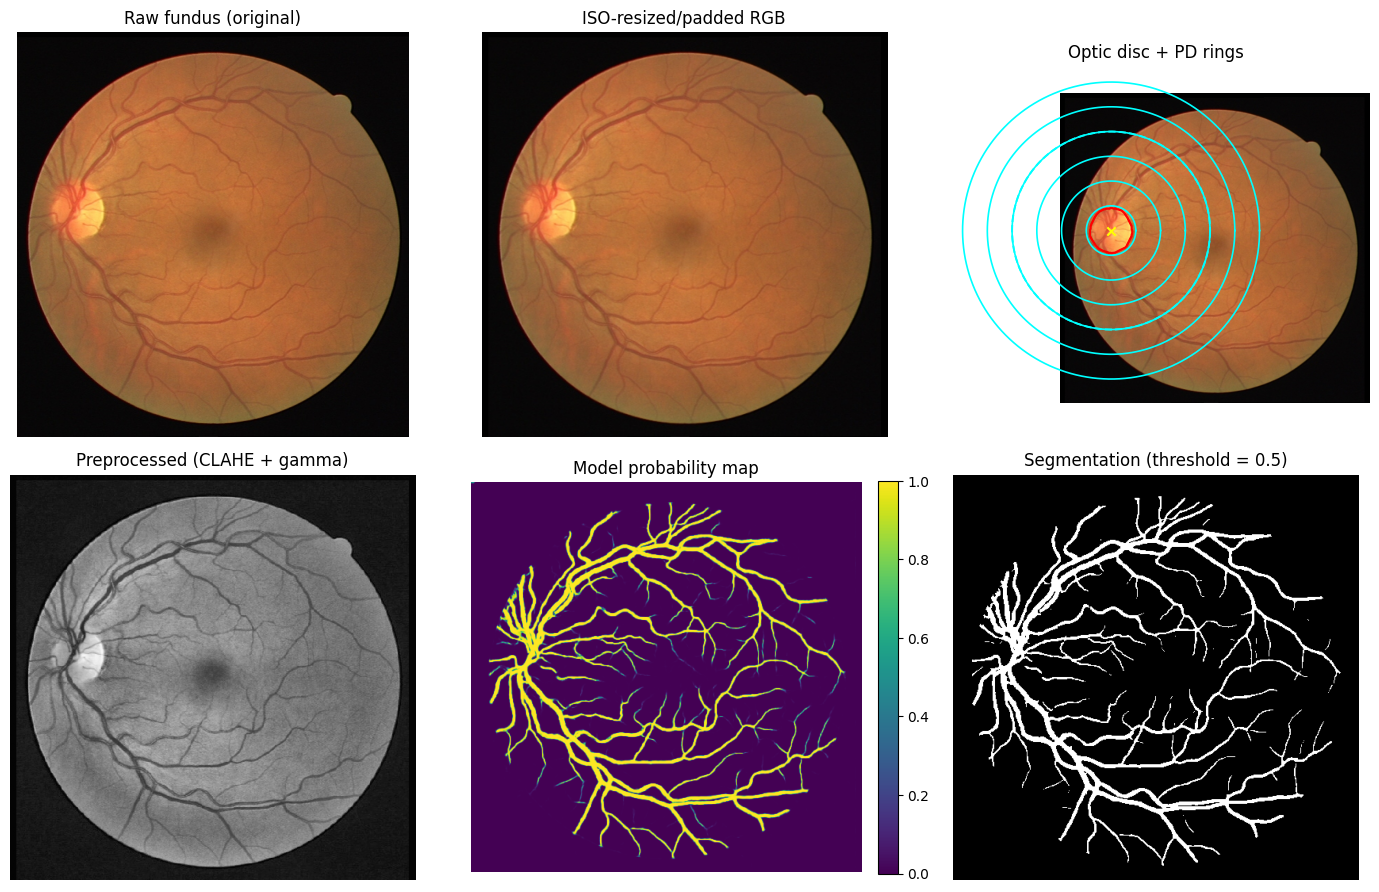

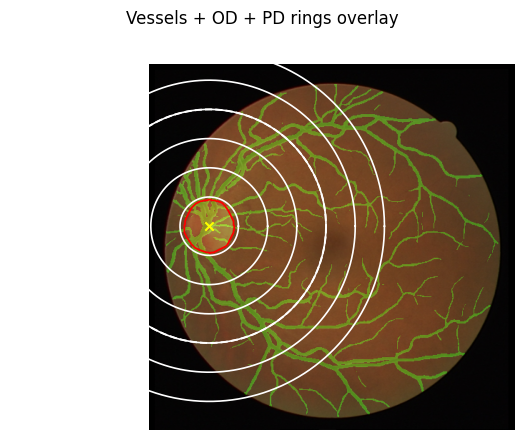

In [8]:
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/01_test.png"

out = run_pipeline_with_ckpt(color_path, ckpt_path)

# 2×3 grid
visualize_grid(out)

# Separate overlay (optional)
visualize_overlay(out)


In [9]:
# Full biomarkers (includes PD-normalized and rings if OD was found)
print(json.dumps(out["biomarkers"], indent=2))


{
  "image_shape": [
    512,
    512
  ],
  "global": {
    "area_density": 0.10198593139648438,
    "length_density_px_inv": 0.03290477024665961,
    "fractal_dimension": 1.5212306624496528,
    "tortuosity_mean": 0.16919785737991333,
    "vc_edt": {
      "median_width": 4.0,
      "iqr_width": 2.4721360206604004,
      "frac_thin_len": 0.6846537741734249,
      "frac_med_len": 0.3052089831565814,
      "frac_thick_len": 0.010137242669993761
    },
    "vc_orth": {
      "median_width": 4.5,
      "iqr_width": 3.5,
      "frac_thin_len": 0.4683484055211804,
      "frac_med_len": 0.3545930509281295,
      "frac_thick_len": 0.17705854355069015
    },
    "median_width": 4.5,
    "iqr_width": 3.5,
    "median_width_PD": 0.054931640625,
    "iqr_width_PD": 0.042724609375,
    "length_density_PD_inv": 220.82017514343264
  },
  "topology": {
    "junction_count": 558.0,
    "endpoint_count": 198.0,
    "junction_density": 0.00212860107421875,
    "endpoint_density": 0.00075531005859375,
 

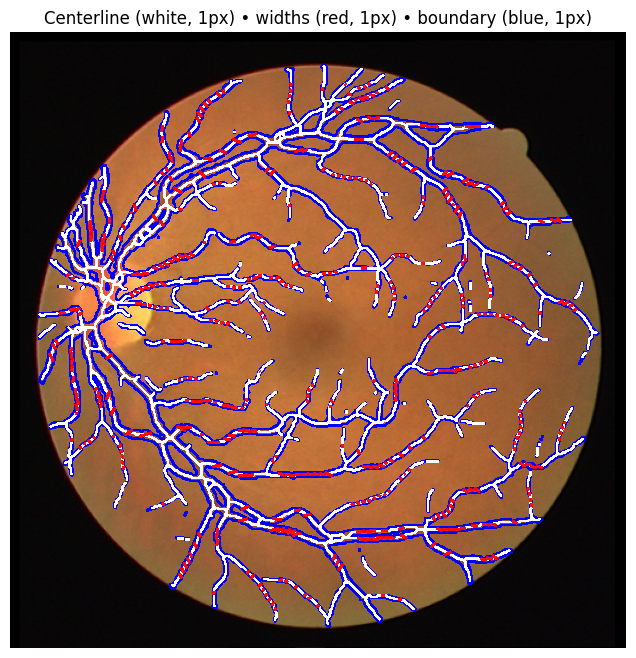

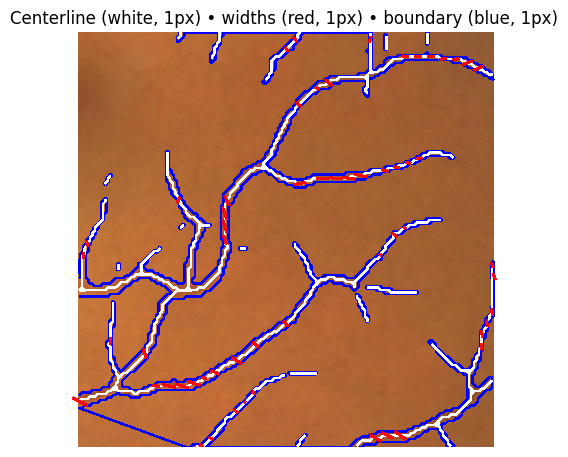

In [ ]:
# geometry
skel  = skeletonize_mask(out["pred_mask"])
graph = build_skeleton_graph(skel)
dist  = distance_transform(out["pred_mask"])

# chords 
chords = collect_orthogonal_chords(
    out["pred_mask"], graph, dist,
    stride_by_arc=1.0,       # denser sampling → more chords
    margin_from_nodes=16.0,  # stay farther from bifurcations
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,           # smoother tangent along centerline
    use_pca=True,            # <<< turn PCA on
    pca_radius_px=7,
    kappa_max=0.18,          # skip sharp turns
    asym_max_ratio=1.6
)
plot_vessel_widths_overlay(
    out["rgb_iso"], out["pred_mask"], graph,
    chords=chords,
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    figsize=(8,8)
)

# zoomed close-up (uses chord center for inclusion)
zoom_center = (int(out["od"]["center_yx"][0] + 80), int(out["od"]["center_yx"][1] + 260))
plot_vessel_widths_overlay(
    out["rgb_iso"], out["pred_mask"], graph,
    chords=chords,
    zoom=(zoom_center[0], zoom_center[1], 80),
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    figsize=(6,6)
)
